<a href="https://colab.research.google.com/github/chalakafernando4/quantum-computing-tutorials/blob/main/07_Hybrid_VQE/VQE_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hybrid Quantum-Classical Algorithms: The Variational Quantum Eigensolver (VQE)

This notebook implements a Variational Quantum Eigensolver (VQE). It demonstrates the state-of-the-art hybrid approach used in modern quantum chemistry and materials science to find the ground state energy of a given quantum system (a Hamiltonian).

## The Limits of Pure Quantum Computing

In the current Noisy Intermediate-Scale Quantum (NISQ) era, our quantum computers cannot run incredibly long, complex algorithms (like Shor's) without noise destroying the data.

To solve real-world problems today, we use **Hybrid Algorithms**. We split the workload:

1. A **Quantum Computer** handles the exponentially difficult math (preparing complex entangled states and measuring their energy).
2. A **Classical Computer** handles the optimization (using machine learning techniques like gradient descent to tweak the quantum system).

## How VQE Works

VQE is essentially a machine learning loop where the quantum computer acts as the neural network.

1. **The Hamiltonian:** We mathematically define the system we want to simulate (e.g., a simple molecule) using Pauli matrices.
2. **The Ansatz (Parameterized Circuit):** We create a quantum circuit with adjustable "knobs" (parameters, usually rotation angles).
3. **The Objective Function:** The quantum computer runs the circuit and measures the energy of the system.
4. **The Classical Optimizer:** A classical algorithm (like COBYLA) looks at the measured energy, adjusts the "knobs" on the quantum circuit, and asks the quantum computer to run it again.

This loop repeats until the classical optimizer finds the exact parameters that result in the lowest possible energy—the **ground state**.

In the code below, we define a toy Hamiltonian and use Qiskit's modern `StatevectorEstimator` primitive alongside SciPy's classical optimizer to find its ground state energy.

---


In [1]:
!pip install qiskit qiskit-aer matplotlib pylatexenc scipy numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 9.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 126.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 103.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 88.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 4.8 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=7e00b761ab72dd7cc4a4f05c0342fcd254a7d6158392b2c9d288d3af12e0a1e1
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


Initializing Hybrid Classical-Quantum Optimization...

Target Hamiltonian:
SparsePauliOp(['ZZ', 'XX'],
              coeffs=[ 1. +0.j, -0.5+0.j])

Starting optimizer loop. Watch the energy decrease...


/tmp/ipykernel_2082/3663024797.py:20: DeprecationWarning: The class ``qiskit.circuit.library.n_local.two_local.TwoLocal`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.n_local instead.
  ansatz = TwoLocal(num_qubits=2, rotation_blocks='ry', entanglement_blocks='cz', reps=1)



--- VQE Results ---
Optimal Parameters Found: [-1.571  4.712 -0.405  5.117]
Calculated Ground State Energy: -1.50000
Total Optimizer Iterations: 94


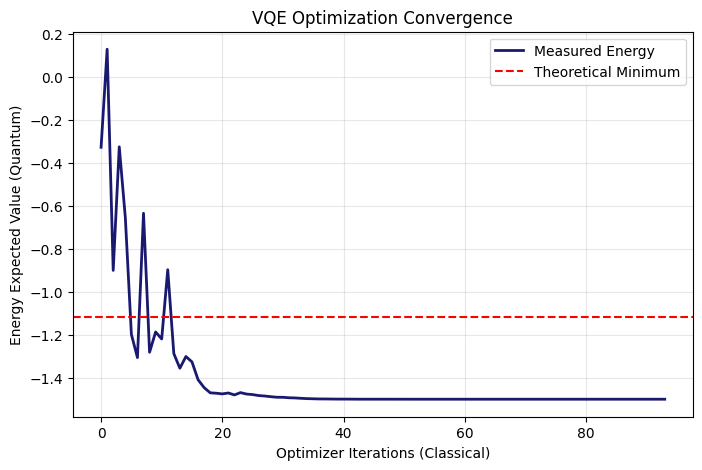


Parameterized Quantum Ansatz:


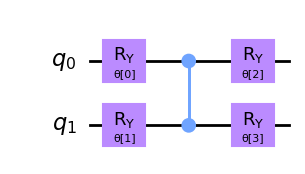

In [2]:
from qiskit.circuit.library import TwoLocal
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import numpy as np

def run_hybrid_vqe():
    """Runs a Variational Quantum Eigensolver using modern Qiskit Primitives."""
    print("Initializing Hybrid Classical-Quantum Optimization...\n")

    # --- 1. Define the Physics (The Hamiltonian) ---
    # We define a simple 2-qubit observable using Pauli matrices.
    # In the real world, this matrix represents the electron interactions in a molecule.
    hamiltonian = SparsePauliOp.from_list([("ZZ", 1.0), ("XX", -0.5)])
    print(f"Target Hamiltonian:\n{hamiltonian}\n")

    # --- 2. Define the Quantum Ansatz (Parameterized Circuit) ---
    # We build a circuit with adjustable rotation gates (Ry) and entanglement (CZ).
    ansatz = TwoLocal(num_qubits=2, rotation_blocks='ry', entanglement_blocks='cz', reps=1)
    num_params = ansatz.num_parameters

    # --- 3. Setup the Hybrid Loop ---
    estimator = StatevectorEstimator()
    energy_history = []

    def cost_function(params):
        """The objective function evaluated by the quantum computer."""
        # Bundle the circuit, the observable, and the current parameters
        pub = (ansatz, hamiltonian, params)

        # Run the quantum simulation
        job = estimator.run([pub])

        # Extract the calculated energy
        energy = job.result()[0].data.evs
        energy_history.append(energy)
        return energy

    # --- 4. The Classical Optimizer ---
    # Start with random parameters (angles between 0 and 2*pi)
    initial_params = np.random.uniform(0, 2*np.pi, num_params)

    print("Starting optimizer loop. Watch the energy decrease...")
    # SciPy's COBYLA algorithm tweaks the parameters to minimize the cost function
    result = minimize(cost_function, initial_params, method='COBYLA', options={'maxiter': 100})

    # --- 5. Output and Visualization ---
    print("\n--- VQE Results ---")
    print(f"Optimal Parameters Found: {np.round(result.x, 3)}")
    print(f"Calculated Ground State Energy: {result.fun:.5f}")
    print(f"Total Optimizer Iterations: {result.nfev}")

    # Plot the convergence graph
    plt.figure(figsize=(8, 5))
    plt.plot(energy_history, color='midnightblue', linewidth=2, label='Measured Energy')
    plt.axhline(y=-1.118, color='red', linestyle='--', label='Theoretical Minimum')
    plt.title("VQE Optimization Convergence")
    plt.xlabel("Optimizer Iterations (Classical)")
    plt.ylabel("Energy Expected Value (Quantum)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # Draw the parameterized quantum circuit
    print("\nParameterized Quantum Ansatz:")
    display(ansatz.decompose().draw('mpl', style='clifford'))

# Execute the hybrid algorithm
run_hybrid_vqe()